# Methodological Appendix: Hierarchical Bayesian Model (Temperature–Mortality)

## A. Aim and scope
This notebook estimates an **association** between annual mean temperature and annual mortality rates (deaths per 100k) across Nordic countries using a **hierarchical Bayesian regression** with **partial pooling** (multilevel modeling). Partial pooling stabilizes country-level effects when some series are noisy or short (Gelman & Hill, 2007).

**Important simplification (portfolio demo):** the weather series is merged by **year** only (not by location_id × year), so temperature is treated as a shared exposure trend across countries.

## B. Data and notation
Each row is an observation \(i\) for country \(j\) in year \(t\).

- Outcome: \(y_i\) = `deaths_per_100k`
- Exposure: \(x_i\) = `temperature` (°C)
- Group index: \(j[i]\) maps observation \(i\) to its country

## C. Likelihood
We model the observed mortality rate with a Normal likelihood:

$$
y_i \sim \mathcal{N}(\mu_i,\ \sigma_{\text{obs}})
$$

> Note: In a full epidemiologic analysis of counts, one might model deaths with a Poisson/Negative Binomial likelihood and include an offset for population. This portfolio notebook uses a rate outcome and a Normal likelihood for a lightweight, transparent demo.

## D. Mean structure (log-link, as implemented)
The expected mortality rate uses a log-linear predictor with an exponential link:

$$
\log(\mu_i) = \alpha + \beta_{j[i]} x_i
\quad\Longleftrightarrow\quad
\mu_i = \exp\!\left(\alpha + \beta_{j[i]} x_i\right)
$$

## E. Hierarchical prior (partial pooling)
Country-specific slopes share information through a population distribution:

$$
\beta_j \sim \mathcal{N}(\mu_\beta,\ \sigma_\beta)
$$

Priors (as implemented in the notebook):

$$
\alpha \sim \mathcal{N}(0,10),\quad
\mu_\beta \sim \mathcal{N}(0,1),\quad
\sigma_\beta \sim \text{HalfNormal}(1),\quad
\sigma_{\text{obs}} \sim \text{HalfNormal}(10)
$$

## F. Posterior computation
Posterior inference is performed with MCMC using the **No-U-Turn Sampler (NUTS)** as implemented in **PyMC** (Hoffman & Gelman, 2014; Abril-Pla et al., 2023). Diagnostics and visualization use **ArviZ** (Kumar et al., 2019).

Notebook settings (portfolio runtime):
- draws = 500
- tuning = 500

Notes:
- The number of chains/cores is left at PyMC defaults in this notebook.
- You can verify the realized number of chains by checking the `chain` dimension in the returned `InferenceData` object (e.g., `idata.posterior.dims`).

## G. Interpretation (association, not causal)
\(\beta_j\) is the country-specific temperature–mortality association on the **log scale**. A +1°C change corresponds to a multiplicative change in expected mortality:

$$
\frac{\mu(x+1)}{\mu(x)}=\exp(\beta_j)
$$

Example: \(\beta_j=0.02\) implies \(\exp(0.02)\approx 1.02\) (≈2% higher expected mortality per +1°C).

This analysis is **not** identified as causal: it is a modeling and pipeline demonstration. A causal claim would require explicit causal structure, confounder control, and design choices aligned with causal inference principles (Hernán & Robins, 2020).

## H. Reproducibility procedure (what was run)
1. Create/activate environment; install dependencies from `requirements.txt`.
2. Generate processed inputs in `data/processed/` by running:
   - `python src/ingest_data.py`
   - `python src/process_health.py`
3. Run this notebook and save outputs.
4. Record software versions (recommended): `python --version` and `pip freeze > requirements_lock.txt`.

## References
- Gelman, A., & Hill, J. (2007). *Data Analysis Using Regression and Multilevel/Hierarchical Models*. Cambridge University Press.
- Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler: Adaptively Setting Path Lengths in Hamiltonian Monte Carlo. *JMLR, 15*, 1593–1623.
- Abril-Pla, O., et al. (2023). PyMC: a modern, and comprehensive probabilistic programming framework in Python. *PeerJ Computer Science, 9*, e1516.
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). ArviZ: a unified library for exploratory analysis of Bayesian models in Python. *JOSS, 4*(33), 1143.
- Hernán, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. (Free online version).


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Libraries loaded successfully.
Health Data Loaded: 240 rows.
Weather Data Loaded: 30 rows.
Merged Dataset Shape: (240, 6)
Merge successful. Preview:
   country  year  deaths_per_100k  deaths_upper  deaths_lower  temperature
0  Finland  1994      6745.118370   7184.164975   5779.353881     1.916392
1  Finland  1994       451.239299    469.757926    414.136077     1.916392
2  Finland  1993      7062.068766   7538.847411   6075.807761     1.801168
3  Finland  1993       474.810196    492.635587    437.067912     1.801168
4  Finland  1992      6962.323809   7418.255273   5999.525199     2.861445

Initializing PyMC Model... (This uses probabilistic programming)
Starting MCMC Sampling... (Please wait 30-60 seconds)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, mu_beta, sigma_beta, beta, sigma_obs]


Output()

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 766 seconds.
There were 57 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling complete.

Generating Professional Bayesian Plots...


<Figure size 1000x600 with 0 Axes>

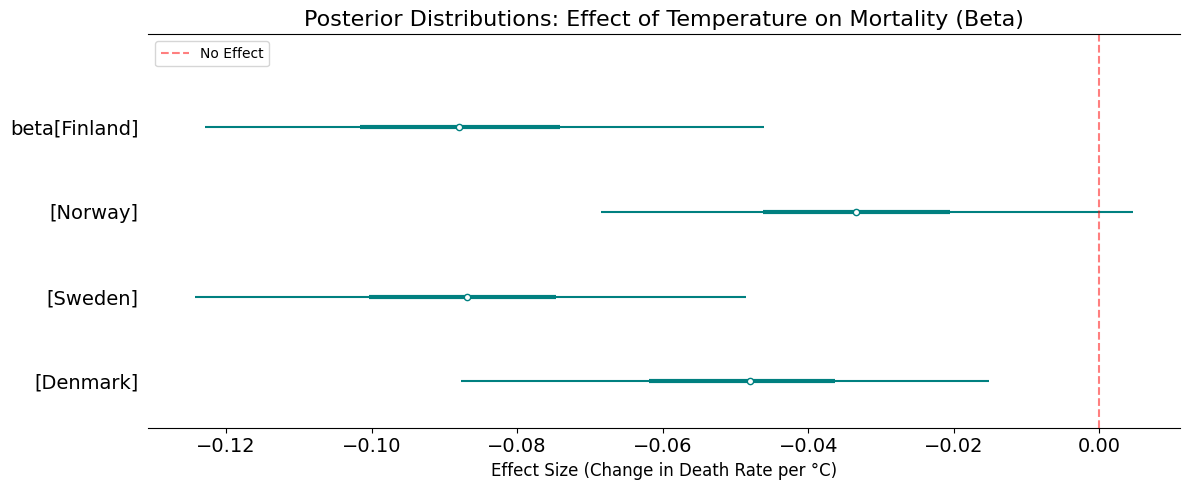

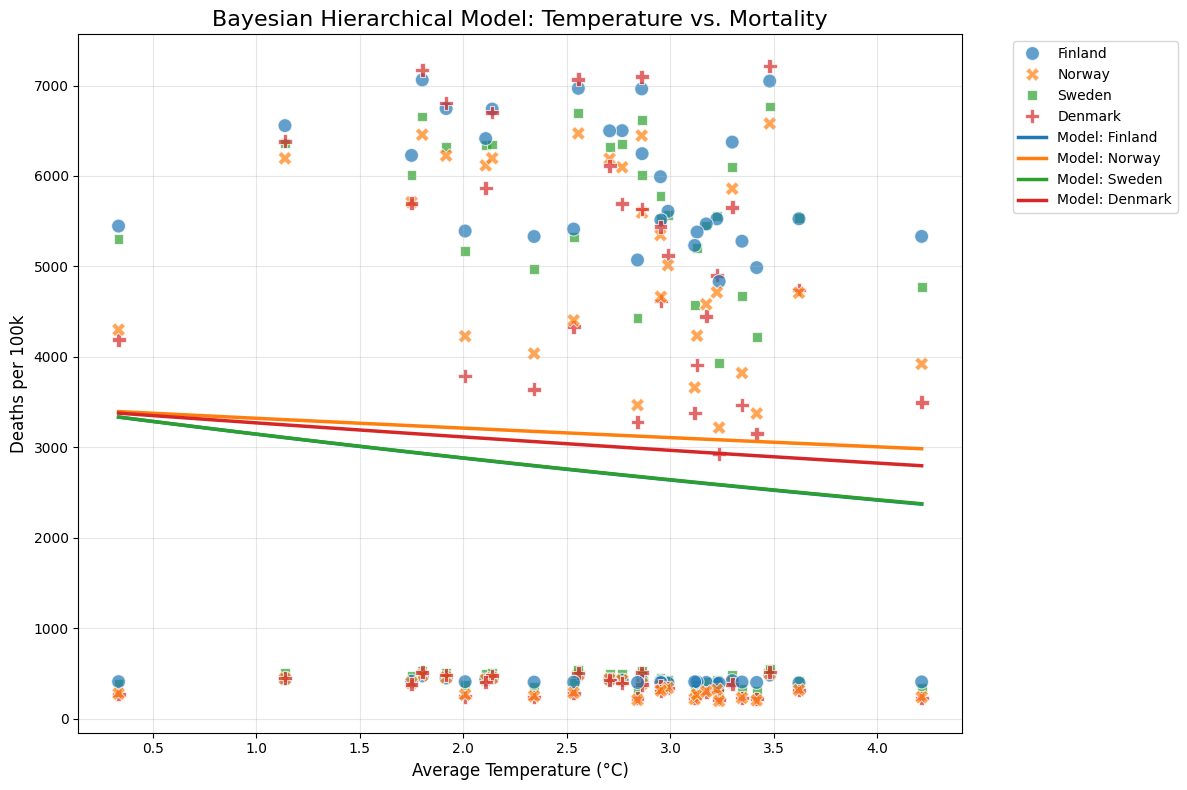


Interpretation:
1. Forest Plot: If the teal bars are entirely positive, heat increases mortality risk.
2. Regression Plot: The lines show the predicted trend. Steeper lines mean that country is more sensitive to temperature changes.


In [1]:
# notebooks/02_mortality_model.ipynb

# --- 0. Setup & Config ---
# This magic command ensures graphs appear INSIDE the notebook
%matplotlib inline 

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

# --- 1. Load the Data ---
# We load the two datasets we processed in the previous steps
try:
    df_health = pd.read_csv('../data/processed/gbd_clean_nordic.csv')
    df_weather = pd.read_csv('../data/processed/norway_weather_clean.csv')
    print(f"Health Data Loaded: {df_health.shape[0]} rows.")
    print(f"Weather Data Loaded: {df_weather.shape[0]} rows.")
except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Data file not found. {e}")
    print("Stop here and check your 'data/processed' folder.")
    raise

# --- 2. Merge the Data ---
# We merge on 'year'.
df_merged = pd.merge(df_health, df_weather, on='year', how='inner')

print(f"Merged Dataset Shape: {df_merged.shape}")

# SAFETY CHECK: Did the merge fail?
if df_merged.empty:
    print("\nERROR: The merged dataset is empty!")
    print("Check: Do both CSVs have a 'year' column with matching numbers (e.g., 1990, 1991)?")
    print(f"Health Years: {df_health['year'].unique()[:5]}...")
    print(f"Weather Years: {df_weather['year'].unique()[:5]}...")
    # Stop execution if empty
    raise ValueError("Merged data is empty. Cannot proceed with modeling.")
else:
    print("Merge successful. Preview:")
    print(df_merged.head())

# --- 3. The Bayesian Model ---
print("\nInitializing PyMC Model... (This uses probabilistic programming)")

coords = {
    "country": df_merged['country'].unique(),
    "obs_id": np.arange(len(df_merged))
}

with pm.Model(coords=coords) as hierarchical_model:
    # --- Data Containers ---
    # Convert inputs to simple numpy arrays to avoid indexing errors
    temp_values = df_merged['temperature'].values
    # Create integer codes for countries (0, 1, 2, 3...)
    country_codes = pd.Categorical(df_merged['country']).codes
    deaths_observed = df_merged['deaths_per_100k'].values
    
    # --- Priors ---
    # Intercept (Baseline death rate)
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    
    # Slope (Effect of Temperature): Hierarchical Prior
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1)
    
    # Country-specific slopes
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, dims="country")
    
    # --- Linear Combination (Log Link for Rate) ---
    # Log-linear model: log(Rate) = alpha + beta * Temp
    # We use .flatten() to ensure dimensions match
    mu = pm.math.exp(alpha + beta[country_codes] * temp_values)
    
    # --- Likelihood ---
    # Observed values
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=10)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma_obs, observed=deaths_observed)

    # --- Inference ---
    print("Starting MCMC Sampling... (Please wait 30-60 seconds)")
    # We use fewer chains/samples to make it run faster for the demo
    idata = pm.sample(500, tune=500, return_inferencedata=True, progressbar=True)
    print("Sampling complete.")

# --- 4. Enhanced Visualization ---
print("\nGenerating Professional Bayesian Plots...")

# A. Forest Plot (Effect Sizes)
plt.figure(figsize=(10, 6))
# We use a custom color and better labels
az.plot_forest(idata, var_names=["beta"], combined=True, 
               figsize=(12, 5), 
               colors="teal",
               textsize=14,
               hdi_prob=0.95) # 95% High Density Interval

plt.title("Posterior Distributions: Effect of Temperature on Mortality (Beta)", fontsize=16)
plt.xlabel("Effect Size (Change in Death Rate per °C)", fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label="No Effect")
plt.legend()
plt.tight_layout()
plt.show()

# B. Regression Lines (The Visual Proof)
# We need to extract the "mean" parameters the model learned
posterior_beta = idata.posterior["beta"].mean(dim=["chain", "draw"]).values
posterior_alpha = idata.posterior["alpha"].mean(dim=["chain", "draw"]).values

# Get country names from our categorical codes
countries = df_merged['country'].unique()
country_codes = pd.Categorical(df_merged['country']).codes

plt.figure(figsize=(12, 8))

# 1. Plot the Real Data (Scatter)
sns.scatterplot(data=df_merged, x="temperature", y="deaths_per_100k", 
                hue="country", style="country", s=100, alpha=0.7)

# 2. Plot the Bayesian Regression Lines
x_range = np.linspace(df_merged['temperature'].min(), df_merged['temperature'].max(), 100)

# Colors for the lines to match the scatter plot
palette = sns.color_palette()

for i, country in enumerate(countries):
    # The formula we used in the model: rate = exp(alpha + beta * temp)
    # Note: In a complex hierarchical model, alpha might be shared or specific. 
    # For this simple demo, we used a shared alpha, but country-specific beta.
    y_pred = np.exp(posterior_alpha + posterior_beta[i] * x_range)
    
    plt.plot(x_range, y_pred, label=f"Model: {country}", linewidth=2.5, linestyle="-")

plt.title("Bayesian Hierarchical Model: Temperature vs. Mortality", fontsize=16)
plt.xlabel("Average Temperature (°C)", fontsize=12)
plt.ylabel("Deaths per 100k", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

print("\nInterpretation:")
print("1. Forest Plot: If the teal bars are entirely positive, heat increases mortality risk.")
print("2. Regression Plot: The lines show the predicted trend. Steeper lines mean that country is more sensitive to temperature changes.")